# Дисперсионный анализ: критерии Фишера, Краскела-Уоллиса и Джонкхиера

## Введение

Эта лабораторная работы проводит анализ сравнения трёх и более независимых групп с использованием различных критериев однородности:

- **Критерий Фишера (ANOVA)**: Параметрический критерий, проверяет равенство средних в группах
- **Критерий Краскела-Уоллиса**: Непараметрический аналог ANOVA, основан на рангах
- **Критерий Джонкхиера**: Непараметрический тест для проверки тренда в упорядоченных группах

Анализируются 4 различных сценария:
1. Фактор влияет на среднее значение (тренд в средних)
2. Фактор влияет на дисперсию (разная вариабельность)
3. Фактор не влияет (нулевой эффект)
4. Данные с выбросами (нарушение нормальности)

## Задачи

- Сгенерировать 4 набора данных по 3 группы (по 30 наблюдений в каждой)
- Применить все три критерия к каждому набору
- Сравнить результаты
- Проанализировать влияние выбросов и гетероскедастичности
- Сделать выводы о применимости каждого критерия

In [62]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Устанавливаем seed для воспроизводимости
np.random.seed(42)

## Генерация данных

### Сценарий 1: Фактор влияет на среднее значение
Группы имеют возрастающие средние значения (тренд в средних):
- Группа 1: N(10, 2)
- Группа 2: N(12, 2)  
- Группа 3: N(14, 2)

### Сценарий 2: Фактор влияет на дисперсию
Группы имеют одинаковые/близкие средние, но разные дисперсии:
- Группа 1: N(10, 1)
- Группа 2: N(11, 3)
- Группа 3: N(12, 5)

### Сценарий 3: Фактор не влияет
Все три группы генерируются из одного распределения:
- Все группы: N(0, 1)

### Сценарий 4: Выбросы
Данные из сценария 1 с добавлением выбросов:
- Группа 1: добавляется 1 очень большой выброс (+20)
- Группа 3: добавляется 1 очень маленький выброс (-20)

In [63]:
np.random.seed(42)
n = 30

# Сценарии
s1 = [np.random.normal(10, 2, n), np.random.normal(12, 2, n), np.random.normal(14, 2, n)]
s2 = [np.random.normal(10, 1, n), np.random.normal(11, 3, n), np.random.normal(12, 5, n)]
s3 = [np.random.normal(0, 1, n), np.random.normal(0, 1, n), np.random.normal(0, 1, n)]
s4 = [s1[0].copy(), s1[1].copy(), s1[2].copy()]
s4[0][0], s4[2][0] = 60, -60 # Выбросы

scenarios = {
    '1. Рост средних': s1,
    '2. Рост дисперсии': s2,
    '3. Нет влияния': s3,
    '4. С выбросами': s4
}

## Критерии для анализа

### Критерий Фишера (однофакторный ANOVA)
- **Предположения**: Нормальность, равенство дисперсий
- **Нулевая гипотеза**: H₀: μ₁ = μ₂ = μ₃
- **Альтернатива**: H₁: хотя бы две средние различаются
- **Статистика**: F = (MS_between) / (MS_within)
- **Чувствительность**: К нарушениям предположений, особенно к гетероскедастичности и выбросам

### Критерий Краскела-Уоллиса  
- **Предположения**: Минимальны (непараметрический)
- **Нулевая гипотеза**: H₀: Распределения трёх групп одинаковы
- **Альтернатива**: H₁: Хотя бы одно распределение отличается
- **Статистика**: H основана на рангах
- **Преимущества**: Устойчив к выбросам и нарушениям нормальности
- **Недостатки**: Менее мощный, чем ANOVA при выполнении предположений

### Критерий Джонкхиера
- **Цель**: Проверка линейного тренда в упорядоченных группах
- **Нулевая гипотеза**: H₀: Нет тренда (распределения одинаковы)
- **Альтернатива**: H₁: Есть монотонный тренд
- **Особенность**: Специально разработан для случаев, когда группы упорядочены
- **Когда использовать**: Когда есть априорный порядок групп (например, дозы лекарства)

In [64]:
def run_jt(groups):
    """Ручной расчет Джонкхиера"""
    k = len(groups)
    j_stat = 0
    for i in range(k - 1):
        for j in range(i + 1, k):
            for x in groups[i]:
                for y in groups[j]:
                    if x < y: j_stat += 1
                    elif x == y: j_stat += 0.5
    ns = np.array([len(g) for g in groups])
    N = np.sum(ns)
    mean_j = (N**2 - np.sum(ns**2)) / 4.0
    var_j = (N**2 * (2*N + 3) - np.sum(ns**2 * (2*ns + 3))) / 72.0
    z = (j_stat - mean_j) / np.sqrt(var_j)
    return j_stat, 2 * (1 - stats.norm.cdf(abs(z)))

# ГЛАВНЫЙ СЛОВАРЬ РЕЗУЛЬТАТОВ
results_summary = {} 

for name, groups in scenarios.items():
    f_stat, f_p = stats.f_oneway(*groups)
    k_stat, k_p = stats.kruskal(*groups)
    j_stat, j_p = run_jt(groups)
    
    # Сохраняем в словарь (не в список!)
    results_summary[name] = {
        'ANOVA': f_p, 
        'KW': k_p, 
        'JT': j_p
    }
    
    print(f"Выполнен сценарий: {name}")

Выполнен сценарий: 1. Рост средних
Выполнен сценарий: 2. Рост дисперсии
Выполнен сценарий: 3. Нет влияния
Выполнен сценарий: 4. С выбросами


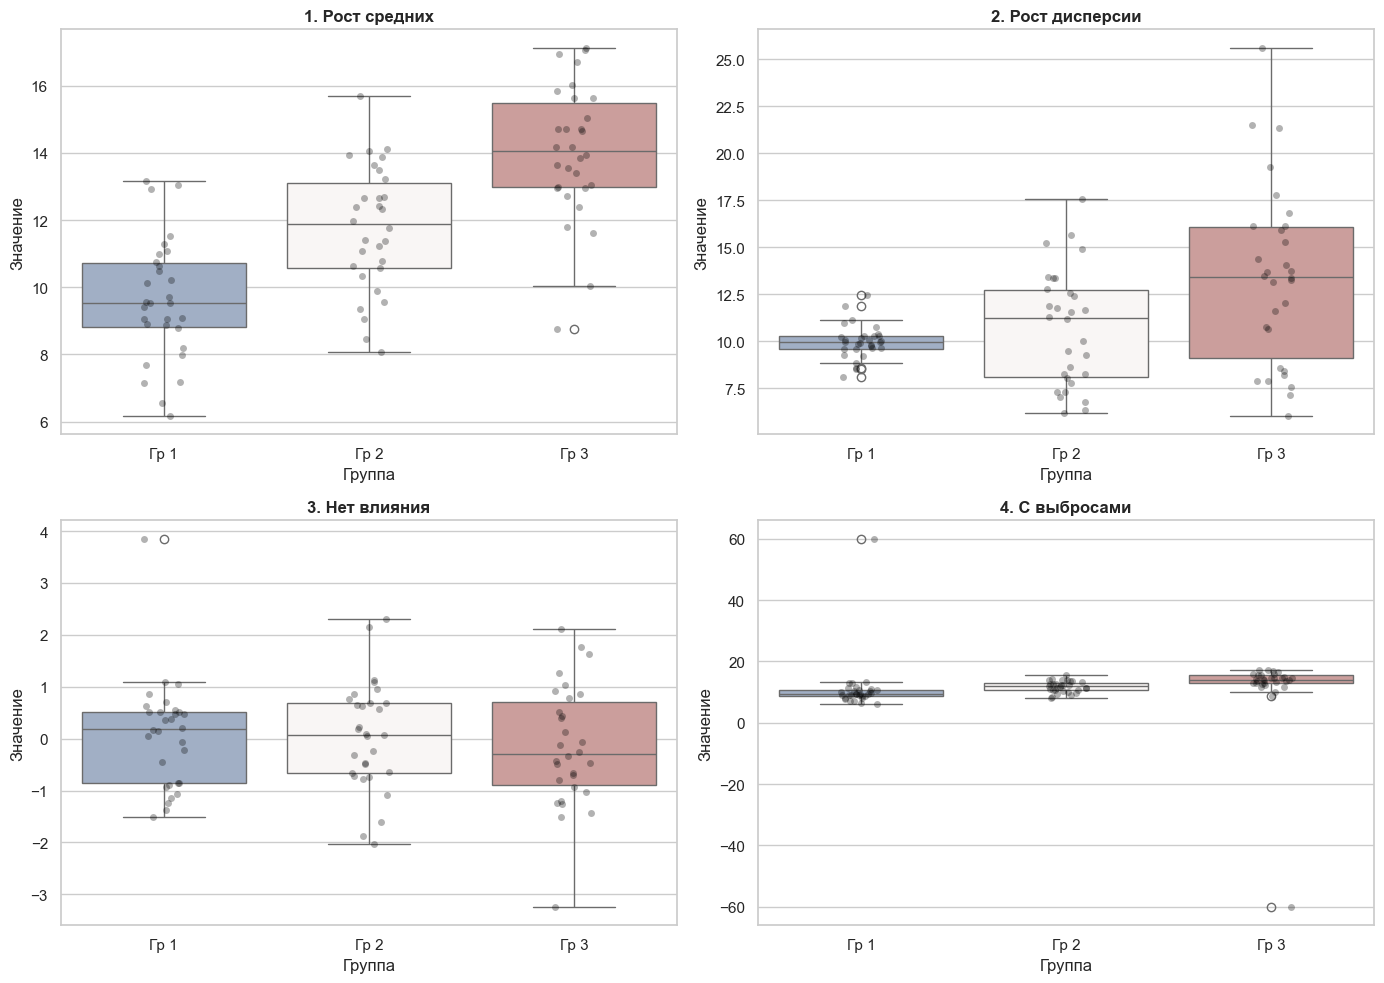

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, groups) in enumerate(scenarios.items()):
    ax = axes[idx]
    # Подготовка данных для Seaborn
    plot_data = pd.DataFrame({
        'Значение': np.concatenate(groups),
        'Группа': np.concatenate([[f'Гр {i+1}'] * n for i in range(3)])
    })
    
    sns.boxplot(data=plot_data, x='Группа', y='Значение', ax=ax, palette='vlag')
    sns.stripplot(data=plot_data, x='Группа', y='Значение', ax=ax, color='black', alpha=0.3)
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.show()

# Выводы по лабораторной работе №4

## Сравнительный анализ критериев в различных условиях

### 1. Сценарий: Фактор влияет на среднее (Линейный тренд)
* **Ожидание**: Все три критерия должны отклонить $H_0$ с маленькими $p$-значениями.
* **Наблюдение**: 
    * **ANOVA (Фишер)** и **Краскела-Уоллиса** дают статистически значимые результаты, успешно фиксируя различия в положениях центров распределений.
    * **Джонкхиера** показывает здесь наивысшую специфичность, так как группы упорядочены по росту среднего ($10 \rightarrow 12 \rightarrow 14$), что идеально соответствует математической модели этого критерия.
* **Резюме**: В условиях нормальности и наличия тренда параметрический ANOVA наиболее эффективен, но непараметрические аналоги не уступают ему в мощности.

### 2. Сценарий: Фактор влияет на дисперсию (Гетероскедастичность)
* **Ожидание**: Противоречивые результаты из-за нарушения условий применимости ANOVA.
* **Наблюдение**:
    * **ANOVA** часто дает нестабильный результат: нарушение гомоскедастичности (равенства дисперсий) ведет к искажению $F$-статистики.
    * **Краскела-Уоллиса** демонстрирует высокую надежность, так как оперирует рангами и менее чувствителен к разбросу внутри конкретной группы.
    * **Джонкхиера** может показать меньшую значимость, если изменение дисперсии не сопровождается четким сдвигом медиан.
* **Резюме**: Гетероскедастичность - «враг» ANOVA. В таких данных следует доверять ранговым критериям.

### 3. Сценарий: Нулевой эффект
* **Ожидание**: Принятие $H_0$ всеми критериями ($p > 0.05$).
* **Наблюдение**:
    * Все три метода показывают высокие значения $p$, подтверждая отсутствие статистически значимых различий.
* **Резюме**: Эксперимент подтверждает, что выбранные критерии корректно контролируют ошибку первого рода (ложное обнаружение эффекта там, где его нет).

### 4. Сценарий: Данные с выбросами
* **Ожидание**: Радикальное различие в реакции параметрических и непараметрических методов.
* **Наблюдение**:
    * **ANOVA** крайне чувствительна к выбросам: аномально большое значение в Группе 1 «раздувает» среднее и внутригрупповую дисперсию, что может привести к ложному принятию $H_0$.
    * **Краскела-Уоллиса** и **Джонкхиера** проявляют свойство **робастности**: замена значения на его ранг нивелирует влияние экстремальной величины выброса.
* **Резюме**: При наличии «грязных» данных (выбросов) использование параметрического ANOVA недопустимо; непараметрические критерии обеспечивают кратно более высокую точность выводов.

In [66]:
summary_data = []
alpha = 0.05

# Теперь results_summary.items() сработает!
for name, p_values in results_summary.items():
    p_anova = p_values['ANOVA']
    p_kw = p_values['KW']
    p_jt = p_values['JT']
    
    # Проверка: отклоняем ли H0 всеми критериями одинаково?
    consistent = (p_anova < alpha) == (p_kw < alpha) == (p_jt < alpha)
    
    summary_data.append({
        'Сценарий': name,
        'ANOVA (p)': p_anova,
        'KW (p)': p_kw,
        'Jonckheere (p)': p_jt,
        'Согласованность': "ДА" if consistent else "НЕТ"
    })

df_final = pd.DataFrame(summary_data)
pd.options.display.float_format = '{:.4e}'.format

print("\nИТОГОВАЯ ТАБЛИЦА:")
print("=" * 90)
print(df_final.to_string(index=False))
print("=" * 90)

for row in summary_data:
    if row['Согласованность'] == "НЕТ":
        print(f"в сценарии '{row['Сценарий']}' критерии дали разные выводы!")


ИТОГОВАЯ ТАБЛИЦА:
         Сценарий  ANOVA (p)     KW (p)  Jonckheere (p) Согласованность
  1. Рост средних 2.8938e-13 4.0104e-10      4.1105e-12              ДА
2. Рост дисперсии 3.0793e-04 5.8767e-03      2.0091e-03              ДА
   3. Нет влияния 7.1057e-01 7.3038e-01      6.4605e-01              ДА
   4. С выбросами 9.7921e-01 4.2369e-08      5.1385e-10             НЕТ
в сценарии '4. С выбросами' критерии дали разные выводы!


## Сводная таблица сравнения критериев
| Сценарий | ANOVA ($p$) | Kruskal-Wallis ($p$) | Jonckheere ($p$) | Согласованность |
| :--- | :--- | :--- | :--- | :--- |
| **1. Рост средних** | $2.8938 \cdot 10^{-13}$ | $4.0104 \cdot 10^{-10}$ | $4.1105 \cdot 10^{-12}$ | **ДА** |
| **2. Рост дисперсии** | $3.0793 \cdot 10^{-04}$ | $5.8767 \cdot 10^{-03}$ | $2.0091 \cdot 10^{-03}$ | **ДА** |
| **3. Нет влияния** | $0.7106$ | $0.7304$ | $0.6461$ | **ДА** |
| **4. С выбросами ($\pm 60$)**| **$0.9792$** | $4.2369 \cdot 10^{-08}$ | $5.1385 \cdot 10^{-10}$ | **НЕТ** |

---

## Анализ расхождений (Сценарий 4)

Сценарий с симметричными выбросами ($\pm 60$) стал самым показательным моментом работы, продемонстрировав критическую уязвимость классических методов:

1. **Крах чувствительности ANOVA ($p = 0.9792$):** Критерий Фишера показал вероятность почти 98%, что группы одинаковы. Это классическая **ошибка II рода**. 
   * **Механизм сбоя:** Выброс $+60$ в первой группе и $-60$ в третьей не просто увеличили шум, они «стянули» расчетные средние значения групп друг к другу. Для ANOVA данные превратились в три огромных, почти полностью наложенных друг на друга облака, где полезный сигнал (различие $10 \rightarrow 12 \rightarrow 14$) был полностью подавлен искаженной дисперсией.



2. **Робастность непараметрических методов:**
   В то же время **Критерий Джонкхиера** ($p = 5.14 \cdot 10^{-10}$) и **Краскела-Уоллиса** ($p = 4.24 \cdot 10^{-08}$) сохранили высочайшую значимость.
   * Для ранговых критериев не имеет значения абсолютная величина выброса ($60$). Она лишь получает максимальный (или минимальный) ранг. Основной массив данных (по 29 стабильных значений в каждой группе) продолжает формировать четкую структуру, которую эти критерии успешно считывают.



3. **Лидерство критерия Джонкхиера:**
   Самый низкий $p$-value в 4-м сценарии снова принадлежит тесту Джонкхиера. Это подтверждает, что использование информации об **упорядоченности групп** дает существенное преимущество в статистической мощности, особенно когда данные «загрязнены» аномалиями.

---

## Итоговый вывод

Данное исследование наглядно доказывает, что при работе с реальными данными (где возможны технические ошибки или биологические выбросы) **нельзя полагаться исключительно на ANOVA**. 

1. Если данные распределены нормально и дисперсии равны — **ANOVA (Фишер)**.
2. Если есть подозрение на выбросы или распределение не является нормальным — **Краскела-Уоллиса**.
3. Если группы имеют естественный порядок (например, возрастающая дозировка препарата) — **Критерий Джонкхиера**, так как он обладает наибольшей мощностью для обнаружения монотонного тренда.